In [ ]:
!pip install numpy==1.23.0

In [ ]:
class SigLayer:
  def forward(self, x):
    out = 1/(1+np.exp(-x))
    return out

  def backward(self, x, dout):
    dx = dout * x * (1.0 - x)
    return dx

In [ ]:
class ReluLayer:
  def forward(self, x):
    if (x >= 0): out = x
    else: out = 0.01 * x
    return out

  def backward(self, dout, x):
    if (x >= 0): dx = dout
    else: dx = dout * 0.01
    return dx

In [ ]:
def StepFunction (x):
  if x <= 0.5:
    out = 0
  #elif x >= 0.33 and x <= 0.66:
    #out = 1
  else:
    out = 1
  return out

<ipython-input-60-e2a5750bb424>:9: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  t = np.zeros((N*CLS_NUM, CLS_NUM), dtype=np.int)


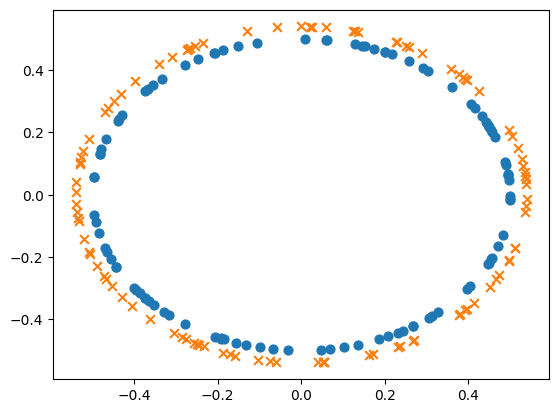

In [60]:
import numpy as np
import matplotlib.pyplot as plt
def load_spiral_data(seed=7777):
    np.random.seed(seed)
    DIM = 2  # 입력 데이터 특성 수
    CLS_NUM = 2  # 분류할 클래스 수
    N = 100  # 클래스 하나 당 샘플 데이터 수
    x = np.zeros((N*CLS_NUM, DIM))
    t = np.zeros((N*CLS_NUM, CLS_NUM), dtype=np.int)
    for j in range(CLS_NUM):
        for i in range(N): # N*j, N*(j+1)):
            rate = i / N
            radius = (j)/25+0.5
            theta = 12.0*rate + np.random.randn()*0.2
            ix = N*j + i
            x[ix] = np.array([radius*np.sin(theta),
                              radius*np.cos(theta)]).flatten()
            t[ix, j] = 1
    return x, t
x, t = load_spiral_data()
N = 100
CLS_NUM = 2
markers = ['o', 'x']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=40, marker=markers[i])
plt.show()

In [ ]:
import random
#나중에 Layer array 만들어서 구현해보기
class Net:
  def __init__(self, input, output):
    self.input = input
    self.output = output
    self.netDepth = 1
    self.layerActive = 1

    self.W = np.array([])
    self.b = np.random.randn(output)

    self.node = np.array([input, output], dtype = int)

    self.forwardArr = np.array([])
    self.backwardArr = np.array([])

    self.dW = np.array([])
    self.db = np.array([])

    self.rel = ReluLayer()
    self.sig = SigLayer()

    self.realLoss = 1000
    self.best = []
  def layer(self, node):
    if self.layerActive == 1:
      self.netDepth += 1
      self.node = np.insert(self.node, -1, node)
      self.b = np.append(self.b, np.random.randn(node))

  def fix(self):
    self.W = np.array([])
    #가중치 랜덤 생성
    for i in range(self.netDepth):
      edgeNum = self.node[i]*self.node[i+1]
      self.W = np.append(self.W, np.random.randn(edgeNum)*np.sqrt(2/self.node[i]))
    self.layerActive = 0

  def forward(self, inputArr):
    #초기화
    self.forwardArr = np.array([])
    #forward arr의 목적은 값*가중치 보존(mulLayer 대체)
    #node arr가 [2, 2, 1, 1]일 때 순전파가 어떻게 일어나냐면
    #x1w1, x2w2, x1w3, x2w4, h1w5, h2w6, o1w7
    #이거 합=h1     이거 합=h2    이거 합=o1
    #그러니까, 가중치는 순서대로 쓴다. 즉, forward arr은
    #[x1, x2, x1, x2, h1, h2, o1] 형태로 형성되면 된다

    #일단 self.input == 2일 때만 고려
    #그러므로, arr는 [a, b] 형태
    x1 = inputArr[0]
    x2 = inputArr[1]
    addArr = np.array([])
    self.forwardArr = np.append(self.forwardArr, (x1, x2) * self.node[1])
    #self.forwardArr = [x1, x2, x1, x2](node가 2, 2, 1, 1일 때)
    #node가 2, 4, 1이랬으면 [x1, x2, x1, x2, x1, x2, x1, x2]
    edgeIndex = 0
    nodeIndex = 0
    for i in range(self.netDepth):#몇층인지 표시하고
      for j in range(self.node[i+1]):
        for k in range(self.node[i]):
          #가중치 개수만큼 돌아라
          x = self.forwardArr[edgeIndex]
          w = self.W[edgeIndex]
          addArr = np.append(addArr, x*w)
          edgeIndex += 1
        b = self.b[nodeIndex]
        nodeIndex += 1
        u = sum(addArr) + b
        if (i != self.netDepth - 1):
          h = self.rel.forward(u)
          self.forwardArr = np.append(self.forwardArr, h)
          addArr = np.array([])
        else:
          #출력값
          o = self.sig.forward(u)
          self.res = o
          self.y = StepFunction(o)
      if (i != self.netDepth - 1):
        self.forwardArr = np.append(self.forwardArr, [(self.forwardArr[-self.node[i+1]:])] * (self.node[i+2]-1))

  def loss(self, label):
    if type(label) == np.ndarray:
      label = label.argmax()
    self.dloss = -(label - self.res)

  def backward(self, lr=1):# +경사 하강법
    #초기화
    self.backwardArr = np.array([])
    self.dW = np.array([])
    self.db = np.array([])
    #활성화 함수가 relu로 고정이므로 역전파 과정은
    #sigLayer>편향>한 개로 나뉨>mulLayer>가중치>reluLayer>편향>둘로 나뉨>mulLayer>가중치>rel..
    #[활성화 함수Layer.backward>편향 조정>AddLayer.backward>MulLayer.backward>가중치 조정]
    #기울기가 몇 개로 나뉘는 지만 달라지고 하는 작업 자체는 똑같다
    #그럼, 나뉘는 기울기를 backward arr에 담으면 되겠군.
    #1개로 나뉨 backward arr = [dout], 2개로 나뉨 backward arr = [dout2, dout1]

    #알고리즘
    #like BFS
    #가중치 분리가 관건
    #편하게 하려면 backwardArr에 RW배열 순서대로 MulLayer.backward할 dout들이 들어있으면 좋겠다

    #순차적으로 반복할 수 있게 배열을 reverse해준다.
    RforwardArr = np.flip(self.forwardArr)
    Rnode = np.flip(self.node)#조정 안하는 애들
    self.W = np.flip(self.W)
    self.b = np.flip(self.b)#조정하는 애들
    edgeIndex = 0
    nodeIndex = 0
    for i in range(self.netDepth): #몇 층인지 표시하고
      for j in range(Rnode[i]): #일단 현재 층 노드 개수만큼 돌아라
        if i == 0:#출력층일 때
          #sigLayer.backward
          self.dout = lr * self.sig.backward(self.res, self.dloss)
          #AddLayer.backward
          self.backwardArr = np.append(self.backwardArr, [self.dout]*Rnode[i+1])
        else:
          #ReluLayer.backward
          self.dout = lr * self.rel.backward(self.backwardArr[edgeIndex], RforwardArr[nodeIndex-self.output])
          #왜 self.output을 nodeIndex에서 빼주냐면
          #self.backwardArr하고 RforwardArr는 출력값을 포함하지 않지만
          #nodeIndex는 출력층의 편향 또한 조정해줘야 하기에 출력층 노드를 포함하므로
        #노드 하나 지났으니까 편향 조정
        self.db = np.append(self.db, lr * self.dout)
        self.b[nodeIndex] -= self.db[-1]
        nodeIndex += 1
        for k in range(Rnode[i+1]):#그 다음 층 노드 개수만큼 돌아라(최종적으로 가중치 개수만큼 돌도록)
          #MulLayer.backward
          #dout1, 2.. 조정+AddLayer.backward
          if (i != self.netDepth - 1):
            self.backwardArr = np.append(self.backwardArr, [self.backwardArr[edgeIndex] * self.W[edgeIndex]] *Rnode[i+2])
            #그 다음 i에서 쓸 거니까 i+2면 그 다음 i기준 바로 앞 노드
          #가중치 조정
          #디버깅#print(f"w{len(self.W)-edgeIndex}: " ,RforwardArr[edgeIndex])#print(f"{edgeIndex} dout : ", self.backwardArr[edgeIndex])#print(f"{len(self.W)-edgeIndex} dout 곱: ", self.W[edgeIndex])#print("진짜 dout: ",self.dout)
          self.dW = np.append(self.dW, lr * RforwardArr[edgeIndex] * self.dout)
          self.W[edgeIndex] -= self.dW[-1]
          edgeIndex += 1
    #되돌려 놓기
    self.W = np.flip(self.W)
    self.b = np.flip(self.b)
    self.dW = np.flip(self.dW)
    self.db = np.flip(self.db)
    #print("backwardArr: ", self.backwardArr)

  def predict(self, x):
    self.score = np.array([])
    for index in range(len(x)):
      self.forward(x[index])
      self.score = np.append(self.score, self.y)
    return self.score

  def realPredict(self, t):
    if type(t) == np.ndarray:
      t = t.argmax(axis = 1)
    tempLoss = sum(abs((t - self.score)))
    if tempLoss < self.realLoss:
      self.realLoss = tempLoss
      self.best = [[*self.W], [*self.b]]
      self.best2 = [self.W[:], self.b[:]] #왜 얘는 self.W가 바뀌면 따라 바뀌지?
      print("best 갱신")
    return tempLoss

In [61]:
model = Net(2, 1)
model.layer(10)
model.fix()
#model.W, model.b = a
print(model.W, model.b)
#print(model.W, model.b)
#x = np.array([[0, 1], [1, 0], [1.5, 1.5], [2, 2], [1, 1], [0, 0]])
#t = np.array([[0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0]])
for i in range(30001):
  idx = np.random.permutation(len(x))
  for index in idx:
    model.forward(x[index])
    model.loss(t[index])
    model.backward()
    #print("W, b: ", model.W, model.b)
    #print("dW, db: ",model.dW, model.db)
  if i%1 == 0:
    print(i, model.predict(x))
    print(i, model.realPredict(t))
    #print(model.W, model.b)
    #print(model.best)
    #print(model.best2)

[-0.41961841  0.71884066 -0.15502234  0.99072213 -0.34338933 -0.85473489
  1.58576554  0.47947322  1.38046665 -0.01054128  0.9609457   0.01170683
  0.59214365  1.69245704  0.20443669 -0.24307964  0.45170577 -0.45098281
 -0.42744123 -2.27135926  0.17887737  0.31232512 -0.62681534 -0.74415202
 -0.67192049 -0.33215638  0.18008632  0.11102772  0.52902183  0.10566648] [-0.28167367 -1.05294328  0.35133472  0.785478    0.39833144  0.05832401
  0.76704854  0.96155332 -0.95995359  0.01384186  0.65857567]
0 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

KeyboardInterrupt: 

In [ ]:
model.realLoss

In [62]:
print(model.W, model.b)
model.W, model.b = model.best
print(model.best)
a = model.best

[-34.35321094   0.66695119  -0.26832817   1.00777112  -0.55744084
  -0.68282916  30.34846723  15.04738474  17.80637926 -19.42684339
  19.8781263  -11.53465716  -4.69126701  27.56809006   0.31771481
  -0.17829625   0.29639198  -0.43094585 -11.26293279 -28.77335467
   7.12349835   0.72887211   0.47169344   7.87767922   5.57280572
   4.90867874   6.22927392   0.11263673   0.71659661   6.06780198] [-12.53490766  -1.18449039  -0.57442912 -13.12237843  -9.11899754
  -8.57860528  -7.62363457  -0.2393587   -1.12073237  -9.92793941
 -30.78297404]
[[-30.16847140119215, 1.4498472061210372, -0.2515113397299559, 0.9970868682722803, -0.5462927858323052, -0.6902063679897161, 27.11091303199918, 11.71036367337898, 15.619731091091914, -16.968873254102974, 17.62623262363923, -9.890159707347745, -3.3735048101031557, 23.52265594490499, 0.32053826518506323, -0.1800809231113436, 0.3135799170654099, -0.4419988611634492, -10.077986625738871, -25.474396824356738, 6.11639729765644, 0.6456591737318432, 0.43963297

[-30.16847140119215, 1.4498472061210372, -0.2515113397299559, 0.9970868682722803, -0.5462927858323052, -0.6902063679897161, 27.11091303199918, 11.71036367337898, 15.619731091091914, -16.968873254102974, 17.62623262363923, -9.890159707347745, -3.3735048101031557, 23.52265594490499, 0.32053826518506323, -0.1800809231113436, 0.3135799170654099, -0.4419988611634492, -10.077986625738871, -25.474396824356738, 6.11639729765644, 0.6456591737318432, 0.4396329778867584, 6.392528522562798, 5.078874546428088, 4.648933591417073, 5.723084084599052, 0.11079524668960894, 0.6731322055308688, 5.673813369868878] [-10.330477299428049, -1.1495547110397824, -0.5507466231823663, -10.913476535445842, -7.878744032989765, -7.881233905824637, -6.031394642894293, -0.23369388232146934, -1.08507016371636, -8.691766010898375, -25.42949720455889]
(128, 128)
(16384, 2)
(16384,)


<ipython-input-60-e2a5750bb424>:9: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  t = np.zeros((N*CLS_NUM, CLS_NUM), dtype=np.int)


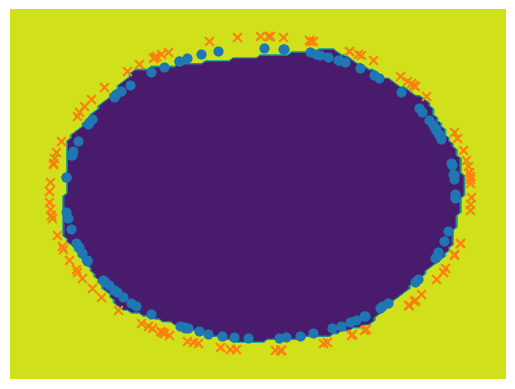

In [63]:
print(model.W, model.b)
# 경계 영역 플롯
h = 0.01
x_min, x_max = x[:, 0].min() - 0.1, x[:, 0].max() + 0.1
y_min, y_max = x[:, 1].min() - 0.1, x[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
print(xx.shape)
X = np.c_[xx.ravel(), yy.ravel()]
print(X.shape)
score = model.predict(X)
print(score.shape)
Z = score.reshape(xx.shape)
plt.contourf(xx, yy, Z)
plt.axis('off')
# 데이터점 플롯
x, t = load_spiral_data()
N = 100
CLS_NUM = 3
markers = ['o', 'x', '^']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=40, marker=markers[i])
#결정 경계 직선
#x = [0, 2]
#y = [(0*model.W[0]+model.b[0])/model.W[1], (2*model.W[0]+model.b[0])/model.W[1]]
#plt.plot(x, y)
plt.show()